# Short-horizon probability calibration and the economics of quoting binaries

Venues now list 5-minute binary contracts on BTC direction ("will price be
higher in 5 minutes?"). Pricing one requires a probability; *quoting* one
requires that probability to be calibrated **and** an answer to a harder
question: conditional on someone trading against your quote, is it still a
good price?

This notebook works through both on public data — 60 days of 1-minute BTC
prices (17,000+ contract windows):

1. A driftless diffusion ("Brownian bridge") model of P(up) from mid-window
   displacement and trailing realized volatility. It is genuinely informative
   (Brier 0.187 vs 0.25 for a coin flip).
2. Its miscalibration is **non-monotone**: short-horizon *continuation* in the
   mid-range (outcomes finish in the displacement's direction more often than
   the bridge implies) and *snapback* in the tails. Platt scaling — the
   default recalibrator — barely helps, because a monotone map in logit space
   cannot fix a non-monotone residual. Isotonic regression (implemented from
   scratch) can.
3. Calibration turns out to be necessary but nowhere near sufficient. A fill
   simulation shows adverse selection costs a near-**constant** ~12–14 cents
   per informed fill *regardless of how much edge you demand at quote time* —
   because a fill caused by the fair value moving through your price
   re-centers the expected outcome at your price. The viable region for a
   maker is a corner: short quote lifetimes × wide edge thresholds × enough
   uninformed flow.

I operate a live maker on 5-minute binary markets; the failure modes
simulated here are ones I have paid for in production. Parameters below are
illustrative, not the live ones.

In [1]:
import time
from math import erf
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import requests

DATA = Path("../data")
CACHE = DATA / "btcusdt_1m.csv"
FORCE_REFRESH = False  # committed outputs are tied to the committed cache

def load_1m(days: int = 60) -> pd.Series:
    if CACHE.exists() and not FORCE_REFRESH:
        df = pd.read_csv(CACHE)
    else:
        end = int(time.time() // 60 * 60 * 1000)
        start_ms = end - days * 24 * 3600 * 1000
        rows, start = [], start_ms
        while start < end:
            r = requests.get(
                "https://api.binance.com/api/v3/klines",
                params={"symbol": "BTCUSDT", "interval": "1m",
                        "startTime": start, "endTime": end, "limit": 1000},
                timeout=15,
            )
            batch = r.json()
            if not isinstance(batch, list) or not batch:
                break
            rows += [(int(k[0]), float(k[4])) for k in batch]
            start = batch[-1][0] + 60_000
            time.sleep(0.05)
        df = pd.DataFrame(rows, columns=["ts", "close"]).drop_duplicates("ts")
        df.to_csv(CACHE, index=False)
    idx = pd.to_datetime(df.ts, unit="ms", utc=True)
    return pd.Series(df.close.values, index=idx).asfreq("1min")

close = load_1m()
print(f"{len(close):,} minutes ({len(close)/1440:.0f} days), "
      f"missing: {close.isna().sum()}")

86,401 minutes (60 days), missing: 0


/Users/nkululeko.kuro/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:34: NotOpenSSLWarning: urllib3 v2.0 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


## 1. The contract and the model

Window: each 5-minute boundary opens a contract paying 1 if
`close(t₀+5) > close(t₀)`, else 0. We price it at the **2-minute mark** —
mid-window, with 3 minutes left — which is where a maker actually has to hold
a quote.

Model: treat log price over the remaining τ minutes as a driftless diffusion
with per-minute volatility σ estimated from the trailing 2 hours of 1-minute
returns (lagged one bar — no lookahead anywhere in the pipeline):

$$ P(\text{up}) \;=\; \Phi\!\left( \frac{\ln(P_t / P_{t_0})}{\sigma\sqrt{\tau}} \right) $$

Displacement already in your favour and little time left → probability near
1; the same displacement with more time left → closer to ½. This is the
textbook prior — exactly the thing worth stress-testing before quoting with
it.

In [2]:
logc = np.log(close)
sigma = logc.diff().rolling(120).std().shift(1)   # trailing 2h, lagged 1 bar

_phi_vec = np.vectorize(erf)
Phi = lambda x: 0.5 * (1 + _phi_vec(x / np.sqrt(2)))

t0s = close.index[close.index.minute % 5 == 0]
frame = pd.DataFrame(index=t0s)
for k in (0, 2, 3, 4, 5):
    frame[f"p{k}"] = logc.reindex(t0s + pd.Timedelta(minutes=k)).values
frame["sigma"] = sigma.reindex(t0s + pd.Timedelta(minutes=2)).values
frame = frame.dropna()

y = (frame.p5 > frame.p0).astype(float).values
p_raw = {k: np.clip(Phi((frame[f"p{k}"] - frame.p0) / (frame.sigma * np.sqrt(5 - k))),
                    1e-4, 1 - 1e-4)
         for k in (2, 3, 4)}   # model fair value at the 2/3/4-minute marks

n = len(y)
n_train = int(0.6 * n)        # time-ordered split: train first 60%, test last 40%
test = slice(n_train, None)

def brier(p, yy):
    return np.mean((p - yy) ** 2)

print(f"{n:,} windows | base rate P(up) = {y.mean():.3f}")
print(f"raw model Brier (all):  {brier(p_raw[2], y):.4f}   (coin flip: 0.2500)")
print(f"raw model Brier (test): {brier(p_raw[2][test], y[test]):.4f}")

17,255 windows | base rate P(up) = 0.495
raw model Brier (all):  0.1868   (coin flip: 0.2500)
raw model Brier (test): 0.1839


## 2. Is it calibrated? Reliability diagram

A reliability diagram bins predictions and compares each bin's mean prediction
with the realized frequency. Perfect calibration sits on the diagonal.

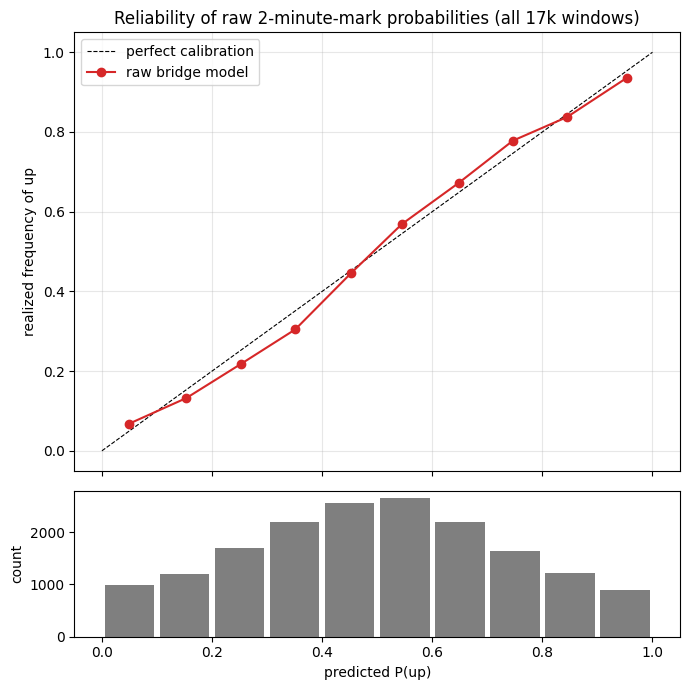

,predicted,realized,n,gap
0,0.048,0.067,980,0.019
1,0.153,0.132,1193,-0.021
2,0.252,0.217,1692,-0.034
3,0.351,0.305,2203,-0.047
4,0.452,0.445,2561,-0.007
5,0.545,0.569,2662,0.024
6,0.648,0.673,2196,0.024
7,0.747,0.778,1641,0.032
8,0.845,0.837,1224,-0.007
9,0.953,0.936,903,-0.018


In [3]:
def reliability(p, yy, n_bins=10):
    edges = np.linspace(0, 1, n_bins + 1)
    bi = np.clip(np.digitize(p, edges) - 1, 0, n_bins - 1)
    pred = np.array([p[bi == b].mean() if (bi == b).any() else np.nan for b in range(n_bins)])
    real = np.array([yy[bi == b].mean() if (bi == b).any() else np.nan for b in range(n_bins)])
    cnt = np.array([(bi == b).sum() for b in range(n_bins)])
    return pred, real, cnt

pred, real, cnt = reliability(p_raw[2], y)

fig, (ax, ax2) = plt.subplots(2, 1, figsize=(7, 7), sharex=True,
                              gridspec_kw={"height_ratios": [3, 1]})
ax.plot([0, 1], [0, 1], "k--", lw=0.8, label="perfect calibration")
ax.plot(pred, real, "o-", color="tab:red", label="raw bridge model")
ax.set_ylabel("realized frequency of up")
ax.legend()
ax.grid(alpha=0.3)
ax.set_title("Reliability of raw 2-minute-mark probabilities (all 17k windows)")
ax2.bar((np.arange(10) + 0.5) / 10, cnt, width=0.09, color="tab:gray")
ax2.set_xlabel("predicted P(up)")
ax2.set_ylabel("count")
plt.tight_layout()
plt.show()

pd.DataFrame({"predicted": pred, "realized": real, "n": cnt,
              "gap": real - pred}).round(3)

The deviation has a *shape*, and the shape is the finding:

- **Mid-range bins (0.1–0.4 and 0.6–0.9): realized is more extreme than
  predicted** — when the model says 0.35, reality says ~0.30; at 0.65,
  reality says ~0.67. Displacement *continues* more often than a driftless
  diffusion implies: short-horizon momentum.
- **Extreme bins flip sign**: at 0.95 reality delivers ~0.94, at 0.05 ~0.07.
  Large displacements partially snap back — consistent with fat-tailed
  1-minute returns: one large print stretches the Gaussian z-score further
  than it stretches reality.

So the model is simultaneously under-confident mid-range and over-confident
in the tails. Keep that in mind for what comes next.

## 3. Platt scaling — the default tool, and why it underwhelms here

Platt scaling fits `p_cal = σ(a·logit(p_raw) + b)` by maximum likelihood —
two parameters, fitted here with Newton's method on the training 60% and
evaluated on the held-out 40%.

In [4]:
def platt_fit(z, yy, iters=25):
    a, b = 1.0, 0.0
    for _ in range(iters):
        p = 1 / (1 + np.exp(-(a * z + b)))
        w = p * (1 - p)
        grad = np.array([((p - yy) * z).sum(), (p - yy).sum()])
        hess = np.array([[(w * z * z).sum(), (w * z).sum()],
                         [(w * z).sum(),      w.sum()]])
        da, db = np.linalg.solve(hess, grad)
        a, b = a - da, b - db
    return a, b

z2 = np.log(p_raw[2] / (1 - p_raw[2]))
a, b = platt_fit(z2[:n_train], y[:n_train])
p_platt = 1 / (1 + np.exp(-(a * z2 + b)))

print(f"fitted a = {a:.3f}, b = {b:.3f}")
print(f"test Brier — raw: {brier(p_raw[2][test], y[test]):.4f}   "
      f"platt: {brier(p_platt[test], y[test]):.4f}")

fitted a = 1.045, b = -0.017
test Brier — raw: 0.1839   platt: 0.1837


`a ≈ 1.05, b ≈ 0` — almost the identity map, and the test Brier barely moves.
This is not because the model is well calibrated (§2 shows it isn't); it is
because **Platt can only apply a monotone, symmetric correction in logit
space**, and our residual is non-monotone: fixing the mid-range
under-confidence requires `a > 1`, fixing the tail over-confidence requires
`a < 1`, and maximum likelihood settles on neither.

The general lesson: *choose the recalibration family from the shape of the
residual, not by default.* (In my live system the residual was a level/slope
bias — there, Platt on a rolling window of realized outcomes was exactly the
right tool. Here it is the wrong one.)

## 4. Isotonic regression, from scratch

Isotonic regression fits the best *monotone step function* from predicted to
realized frequency — flexible enough to bend differently in different ranges.
The classic fitting algorithm is Pool Adjacent Violators (PAV):

          test Brier  test log-loss
raw           0.1839         0.5452
platt         0.1837         0.5449
isotonic      0.1833         0.5458


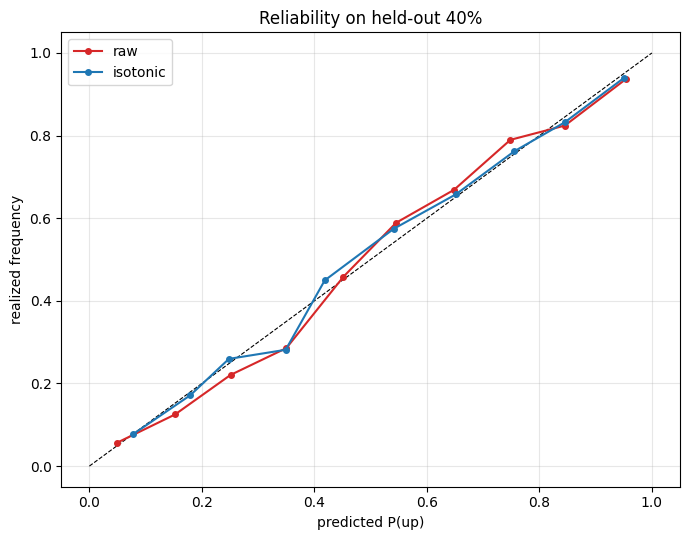

In [5]:
def pav_fit(p, yy):
    """Pool Adjacent Violators. Returns a step-function calibrator."""
    order = np.argsort(p)
    ps, ys = p[order], yy[order]
    vals, wts, brk = [], [], []
    for i in range(len(ys)):
        vals.append(ys[i]); wts.append(1.0); brk.append(ps[i])
        while len(vals) > 1 and vals[-2] >= vals[-1]:      # violator: pool
            v, w = vals.pop(), wts.pop(); brk.pop()
            vals[-1] = (vals[-1] * wts[-1] + v * w) / (wts[-1] + w)
            wts[-1] += w
    xs, vs = np.array(brk), np.array(vals)
    def calibrate(q):
        j = np.searchsorted(xs, q, side="right") - 1
        return vs[np.clip(j, 0, len(vs) - 1)]
    return calibrate

iso = pav_fit(p_raw[2][:n_train], y[:n_train])
p_iso = iso(p_raw[2])

rows = {}
for name, p in [("raw", p_raw[2]), ("platt", p_platt), ("isotonic", p_iso)]:
    pc = np.clip(p, 1e-9, 1 - 1e-9)
    rows[name] = {
        "test Brier": brier(p[test], y[test]),
        "test log-loss": -(y[test] * np.log(pc[test])
                           + (1 - y[test]) * np.log(1 - pc[test])).mean(),
    }
summary = pd.DataFrame(rows).T
print(summary.round(4))

fig, ax = plt.subplots(figsize=(7, 5.5))
ax.plot([0, 1], [0, 1], "k--", lw=0.8)
for name, p, c in [("raw", p_raw[2], "tab:red"),
                   ("isotonic", p_iso, "tab:blue")]:
    pr, re, _ = reliability(p[test], y[test])
    ax.plot(pr, re, "o-", color=c, label=name, ms=4)
ax.set_xlabel("predicted P(up)"); ax.set_ylabel("realized frequency")
ax.set_title("Reliability on held-out 40%")
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

Isotonic improves test Brier where Platt gave nothing, and the test-set
reliability curve hugs the diagonal. Two honest footnotes: the improvement is
small in headline terms — the miscalibration is a few points of probability,
which is invisible in Brier but material when your quoting margin is itself a
few points — and isotonic's **log-loss is marginally worse than raw**, a known
artifact of hard step values near 0/1 (a production version floors and caps
the steps, or blends isotonic with a parametric map). The point is not that
isotonic is magic; it is that the recalibrator must match the residual's
shape.

## 5. The economics: calibrated ≠ quotable

Now the part that actually decides P&L. Suppose at the 2-minute mark we post
a **bid** on the YES side at `p̂ − δ`: we demand δ of edge versus our
calibrated fair value. The quote rests until it is cancelled. Two things can
hit it:

- **Informed flow / stale-quote pickoff:** the fair value moves down through
  our bid before we cancel — modeled here as
  `min(p̂₃, p̂₄) ≤ bid` for a quote left working 2 minutes (TTL=2), or
  `p̂₃ ≤ bid` if we cancel after 1 minute (TTL=1).
- **Uninformed flow:** with some probability π per quote, someone trades at
  our price for reasons unrelated to fair value (hedging, lottery demand).

Each fill pays out `y − bid`. Everything is evaluated on the held-out 40%
only. Deliberate simplifications: no queue, no fees, our own model is the
"true" fair — which *flatters* the maker, making the result below a lower
bound on how bad adverse selection is.

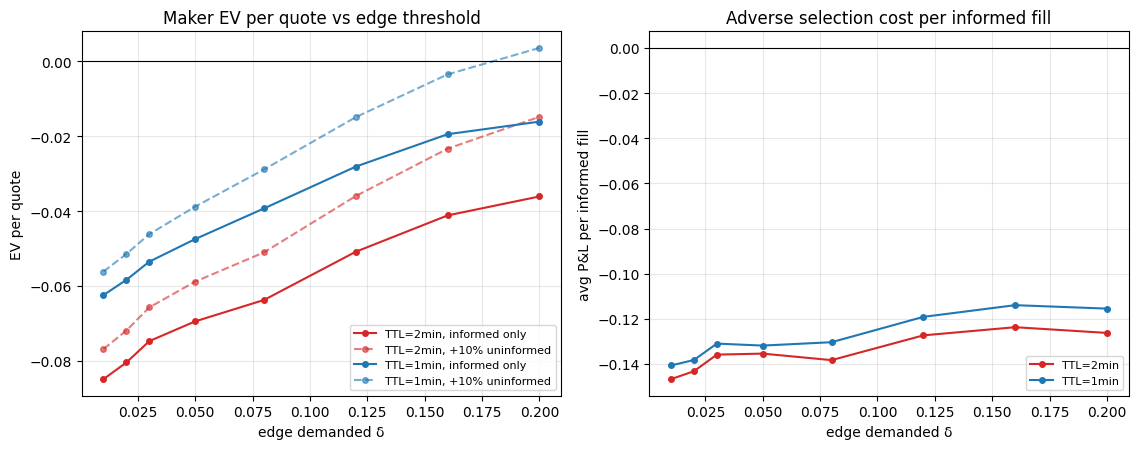

informed fill rate  avg pnl per informed fill  \
TTL=2min 0.01              0.5790                    -0.1467   
         0.02              0.5620                    -0.1432   
         0.03              0.5504                    -0.1358   
         0.05              0.5132                    -0.1354   
         0.08              0.4611                    -0.1383   
         0.12              0.3995                    -0.1273   
         0.16              0.3327                    -0.1237   
         0.20              0.2859                    -0.1262   
TTL=1min 0.01              0.4442                    -0.1406   
         0.02              0.4224                    -0.1382   
         0.03              0.4086                    -0.1310   
         0.05              0.3602                    -0.1318   
         0.08              0.3014                    -0.1303   
         0.12              0.2359                    -0.1191   
         0.16              0.1707                    -0.1139   
         0.20              0.1393                    -0.1155   

               EV/quote (informed only)  EV/quote (+10% uninformed)  
TTL=2min 0.01                   -0.0849                     -0.0769  
         0.02                   -0.0805                     -0.0719  
         0.03                   -0.0748                     -0.0657  
         0.05                   -0.0695                     -0.0589  
         0.08                   -0.0638                     -0.0510  
         0.12                   -0.0509                     -0.0360  
         0.16                   -0.0412                     -0.0233  
         0.20                   -0.0361                     -0.0148  
TTL=1min 0.01                   -0.0625                     -0.0562  
         0.02                   -0.0584                     -0.0515  
         0.03                   -0.0535                     -0.0462  
         0.05                   -0.0475                     -0.0388  
         0.08                   -0.0393                     -0.0289  
         0.12                   -0.0281                     -0.0149  
         0.16                   -0.0194                     -0.0034  
         0.20                   -0.0161                      0.0036

In [6]:
p2c, p3c, p4c = iso(p_raw[2]), iso(p_raw[3]), iso(p_raw[4])
rng = np.random.default_rng(7)
PI = 0.10                                   # uninformed fill prob per quote
uninformed = rng.random(n) < PI

def maker_ev(delta, ttl):
    bid = p2c[test] - delta
    quotable = (bid > 0.02) & (bid < 0.98)
    moved = (np.minimum(p3c, p4c)[test] if ttl == 2 else p3c[test]) <= bid
    inf_fill = quotable & moved
    uni_fill = quotable & uninformed[test] & ~inf_fill
    pnl_inf = np.where(inf_fill, y[test] - bid, 0.0)
    pnl_uni = np.where(uni_fill, y[test] - bid, 0.0)
    nq = quotable.sum()
    return {
        "informed fill rate": inf_fill.sum() / nq,
        "avg pnl per informed fill": pnl_inf[inf_fill].mean() if inf_fill.any() else np.nan,
        "EV/quote (informed only)": pnl_inf.sum() / nq,
        f"EV/quote (+{PI:.0%} uninformed)": (pnl_inf + pnl_uni).sum() / nq,
    }

deltas = np.array([0.01, 0.02, 0.03, 0.05, 0.08, 0.12, 0.16, 0.20])
grid = {(f"TTL={t}min", d): maker_ev(d, t) for t in (2, 1) for d in deltas}
grid = pd.DataFrame(grid).T

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11.5, 4.6))
for t, c in [(2, "tab:red"), (1, "tab:blue")]:
    sub = grid.loc[f"TTL={t}min"]
    ax1.plot(deltas, sub["EV/quote (informed only)"], "o-", color=c,
             label=f"TTL={t}min, informed only", ms=4)
    ax1.plot(deltas, sub[f"EV/quote (+{PI:.0%} uninformed)"], "o--", color=c,
             alpha=0.6, label=f"TTL={t}min, +{PI:.0%} uninformed", ms=4)
    ax2.plot(deltas, sub["avg pnl per informed fill"], "o-", color=c,
             label=f"TTL={t}min", ms=4)
ax1.axhline(0, color="k", lw=0.8)
ax1.set_xlabel("edge demanded δ"); ax1.set_ylabel("EV per quote")
ax1.set_title("Maker EV per quote vs edge threshold")
ax1.legend(fontsize=8); ax1.grid(alpha=0.3)
ax2.axhline(0, color="k", lw=0.8)
ax2.set_xlabel("edge demanded δ"); ax2.set_ylabel("avg P&L per informed fill")
ax2.set_title("Adverse selection cost per informed fill")
ax2.legend(fontsize=8); ax2.grid(alpha=0.3)
plt.tight_layout(); plt.show()

grid.round(4)

Three structural facts fall out:

1. **Adverse selection per informed fill is ~constant (−0.12 to −0.14)
   no matter how much edge you demand.** Demanding more edge does not make
   informed fills better — conditional on the fair value reaching your
   price, the expected outcome has re-centered *at* your price, and your
   pre-fill edge is gone. δ only reduces *how often* it happens.
2. **Quote lifetime is a first-class risk parameter.** Halving the TTL cuts
   the informed fill rate by ~a third across the whole δ range — comparable
   to several cents of extra edge, and free.
3. **The maker's viable region is a corner.** Even with 10% uninformed flow,
   EV per quote crosses zero only at short TTL × wide δ. With no uninformed
   flow it never does: against purely informed flow in a transparent
   underlying, *there is no quoting strategy that wins*. Who fills you
   matters more than what you quote.

This reframes two mechanisms that look like conservative tuning but are
actually existence conditions for the strategy:

- a **minimum-edge gate** (refuse to quote when model edge < threshold), and
- **aggressive quote TTLs with reliable cancels** — and because cancels and
  fills race on the wire, an order/fill reconciliation layer that detects
  the fills you didn't know you took (see `src/showcase/reconciliation.py`,
  whose design came directly from this failure mode).

## 6. What changes in production

Beyond the simulation's perimeter, the live version of this strategy deals
with: recalibration on a *rolling* window of realized outcomes (regimes
drift); resolution-source risk (the contract settles on an oracle's print,
not your feed's); post-only orders that would cross being rejected or
converted; inventory caps per window; and circuit breakers driven by
realized markout rather than model EV. Each of those exists because a
simulation like §5, run honestly, says the naive version loses.

## 7. Conclusions

1. A two-parameter diffusion prior is a genuinely informative 5-minute
   probability model — and still miscalibrated in a structured, exploitable
   way (continuation mid-range, snapback in tails).
2. Recalibration family selection is part of the modeling, not a
   post-processing detail: Platt fails here for a reason you can see in the
   reliability diagram before fitting anything.
3. Calibration is the entry ticket, not the edge. The maker's problem is
   dominated by *conditional* expectations — value given that you traded —
   and those are governed by quote lifetime and flow composition, which is
   where the engineering effort belongs.